In [3]:
# --- Core Libraries ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Audio Processing ---
import librosa
import librosa.display
import scipy.signal
import parselmouth

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Utilities ---
from tqdm import tqdm
from collections import Counter

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# --- DATA LOADING AND PARSING (from teammate) ---

EMODB_PATH = r"C:\College_work\Sem 4-2\ssp\Project\emoDB\wav" # IMPORTANT: Change this path!

def map_emodb_emotion(code):
    return {
        'W': 'angry', 'L': 'boredom', 'E': 'disgust',
        'A': 'fear', 'F': 'happy', 'T': 'sad', 'N': 'neutral'
    }.get(code)

def parse_emodb_filename(filename):
    speaker_id = filename[:2]
    emotion_code = filename[5]
    emotion = map_emodb_emotion(emotion_code)
    return speaker_id, emotion

# Create the initial DataFrame
data = []
for file in os.listdir(EMODB_PATH):
    if file.endswith(".wav"):
        speaker, emotion = parse_emodb_filename(file)
        data.append({
            "file_path": os.path.join(EMODB_PATH, file),
            "speaker": speaker,
            "emotion": emotion
        })

df = pd.DataFrame(data)

print("Initial DataFrame created successfully.")
print("Original data distribution:")
print(df['emotion'].value_counts())
df.head()

Initial DataFrame created successfully.
Original data distribution:
emotion
angry      127
boredom     81
neutral     79
happy       71
fear        69
sad         62
disgust     46
Name: count, dtype: int64


,file_path,speaker,emotion
0,C:\College_work\Sem 4-2\ssp\Project\emoDB\wav\...,03,happy
1,C:\College_work\Sem 4-2\ssp\Project\emoDB\wav\...,03,neutral
2,C:\College_work\Sem 4-2\ssp\Project\emoDB\wav\...,03,angry
3,C:\College_work\Sem 4-2\ssp\Project\emoDB\wav\...,03,happy
4,C:\College_work\Sem 4-2\ssp\Project\emoDB\wav\...,03,neutral


gender   female  male
emotion              
angry        67    60
boredom      46    35
disgust      35    11
fear         33    36
happy        44    27
neutral      40    39
sad          37    25


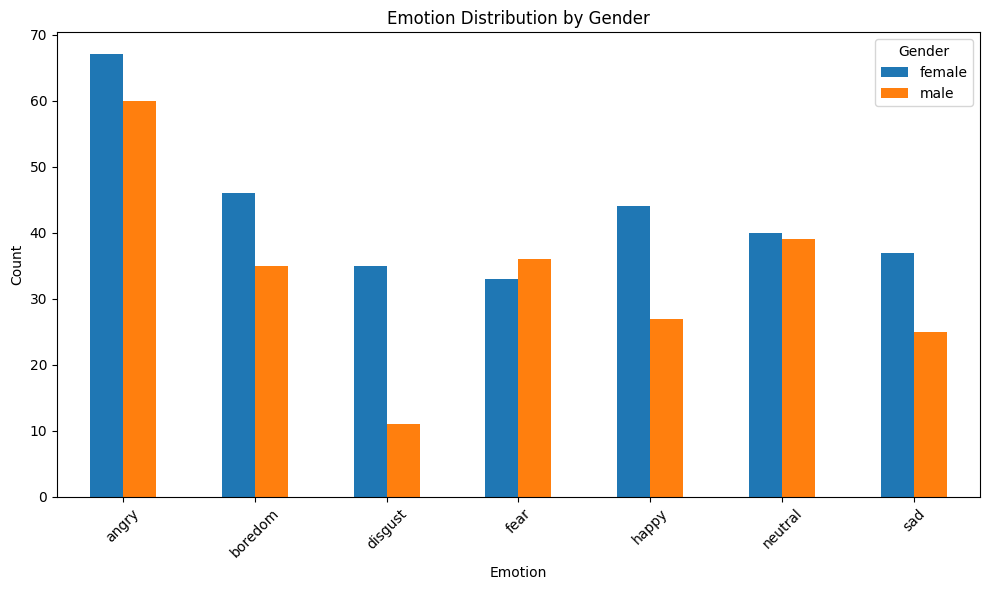

In [5]:
# visualization of emotions and speaker

speaker_gender = {
    '03': 'male',
    '08': 'female',
    '09': 'female',
    '10': 'male',
    '11': 'male',
    '12': 'male',
    '13': 'female',
    '14': 'female',
    '15': 'male',
    '16': 'female'
}
df["gender"] = df["speaker"].map(speaker_gender)

# print(df.head())

gender_emotion_counts = df.groupby(["emotion", "gender"]).size().unstack()

print(gender_emotion_counts)
import matplotlib.pyplot as plt

gender_emotion_counts.plot(kind='bar', figsize=(10, 6))

plt.title("Emotion Distribution by Gender")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()

plt.show()

gender
female    302
male      233
Name: count, dtype: int64


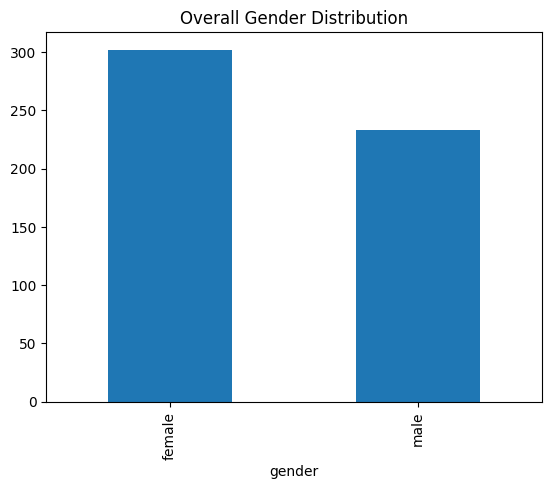

In [6]:
print(df["gender"].value_counts())
df["gender"].value_counts().plot(kind='bar')
plt.title("Overall Gender Distribution")
plt.show()

In [7]:
# --- SAFE AUDIO AUGMENTATION ---

def add_noise(signal, noise_factor=0.005):
    """Adds random Gaussian noise to the signal."""
    noise = np.random.normal(0, noise_factor, len(signal))
    return signal + noise
    
def time_stretch(signal, stretch_rate=1.1):
    """Stretches the signal without altering pitch."""
    return librosa.effects.time_stretch(signal, rate=stretch_rate)

# --- CONFIGURATION ---
TARGET_COUNT_PER_CLASS = 130 # We will augment until every class has 130 samples.
SAMPLE_RATE = 16000

# --- MASTER DATA LISTS ---
X_audio = [] # This will hold the raw audio arrays
y_audio = [] # This will hold the corresponding emotion labels

print(f"Balancing all classes to {TARGET_COUNT_PER_CLASS} samples...")

# Loop through each unique emotion
for emotion in df["emotion"].unique():
    
    emotion_df = df[df["emotion"] == emotion]
    original_samples = list(emotion_df['file_path'])
    
    current_count = len(original_samples)
    print(f"\nProcessing emotion: '{emotion}'")
    print(f"Original samples: {current_count}")

    # Add all original audio signals to our master lists
    for file_path in original_samples:
        signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)
        X_audio.append(signal)
        y_audio.append(emotion)
    
    # Check if augmentation is needed
    samples_to_generate = TARGET_COUNT_PER_CLASS - current_count
    
    if samples_to_generate > 0:
        print(f"Augmenting with {samples_to_generate} new samples...")
        
        # Loop to generate the needed number of augmented samples
        for i in range(samples_to_generate):
            # Pick a random original file from this class to augment
            random_file = original_samples[i % len(original_samples)]
            
            # Load the signal
            signal, _ = librosa.load(random_file, sr=SAMPLE_RATE)
            
            # Randomly choose between our two SAFE augmentation types
            if np.random.rand() < 0.5: # 50% chance for noise
                aug_signal = add_noise(signal)
            else: # 50% chance for time-stretch
                aug_signal = time_stretch(signal)
            
            # Add the new augmented signal to our master lists
            X_audio.append(aug_signal)
            y_audio.append(emotion)

print("\n--- Augmentation Complete ---")
print(f"Total samples in X_audio: {len(X_audio)}")
print("Final class distribution:")
# Use Counter to show the final balanced counts
final_counts = Counter(y_audio)
for emotion, count in final_counts.items():
    print(f"- {emotion}: {count}")

Balancing all classes to 130 samples...

Processing emotion: 'happy'
Original samples: 71
Augmenting with 59 new samples...

Processing emotion: 'neutral'
Original samples: 79
Augmenting with 51 new samples...

Processing emotion: 'angry'
Original samples: 127
Augmenting with 3 new samples...

Processing emotion: 'sad'
Original samples: 62
Augmenting with 68 new samples...

Processing emotion: 'fear'
Original samples: 69
Augmenting with 61 new samples...

Processing emotion: 'boredom'
Original samples: 81
Augmenting with 49 new samples...

Processing emotion: 'disgust'
Original samples: 46
Augmenting with 84 new samples...

--- Augmentation Complete ---
Total samples in X_audio: 910
Final class distribution:
- happy: 130
- neutral: 130
- angry: 130
- sad: 130
- fear: 130
- boredom: 130
- disgust: 130


In [13]:
# --- PHASE 3: UNIFIED FEATURE EXTRACTION ---

# This cell contains all our specialized DSP functions.
# We are defining them again here to make the notebook clean and self-contained.

N_MFCC = 13 # Number of MFCC coefficients

# --- FUNCTION 1: VOWEL ISOLATION ---
def isolate_vowels(y, sr, frame_length=2048, hop_length=512):
    energy = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    
    # Normalize
    if np.max(energy) > 0: energy_norm = energy / np.max(energy)
    else: energy_norm = energy
    if np.max(zcr) > 0: zcr_norm = zcr / np.max(zcr)
    else: zcr_norm = zcr
    
    # Tuned thresholds for stricter vowel detection
    ENERGY_THRESHOLD = 0.4
    ZCR_THRESHOLD = 0.15
    
    vowel_mask_frames = (energy_norm > ENERGY_THRESHOLD) & (zcr_norm < ZCR_THRESHOLD)
    
    vowel_mask_samples = np.zeros_like(y, dtype=bool)
    for i, is_vowel in enumerate(vowel_mask_frames):
        if is_vowel:
            start_sample = i * hop_length
            end_sample = start_sample + frame_length
            vowel_mask_samples[start_sample:end_sample] = True
            
    return vowel_mask_samples

# --- FUNCTION 2: PITCH MARK EXTRACTION (NO PLOT) ---
def extract_pitch_marks_no_plot(y, sr, vowel_mask_samples):
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch()
        pulses = parselmouth.praat.call([snd, pitch], "To PointProcess (cc)")
        num_points = parselmouth.praat.call(pulses, "Get number of points")
        
        valid_marks = []
        for i in range(1, num_points + 1):
            time = parselmouth.praat.call(pulses, "Get time from index", i)
            idx = int(time * sr)
            if idx < len(vowel_mask_samples) and vowel_mask_samples[idx]:
                valid_marks.append(time)
        return valid_marks
    except: # Praat can sometimes fail on very noisy or short audio
        return []

# --- FUNCTION 3: FEATURE SETS (Mean/Variance for SVM) ---
def extract_setup1_mean_var(signal, sr):
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=N_MFCC)
    return np.hstack([np.mean(mfccs, axis=1), np.var(mfccs, axis=1)])

def extract_setup2_vowels_only(y, sr, vowel_mask_samples):
    y_vowels_only = np.where(vowel_mask_samples, y, 0)
    rms_energy = librosa.feature.rms(y=y_vowels_only)[0]
    valid_frame_indices = np.where(rms_energy > 0.001)[0]
    
    if len(valid_frame_indices) == 0: return np.zeros(N_MFCC * 2) # Return zeros if no vowels found
    
    mfccs = librosa.feature.mfcc(y=y_vowels_only, sr=sr, n_mfcc=N_MFCC)
    valid_mfcc_frames = mfccs[:, valid_frame_indices]
    return np.hstack([np.mean(valid_mfcc_frames, axis=1), np.var(valid_mfcc_frames, axis=1)])

# --- FUNCTION 4: SETUP 4 - The HYBRID MODEL (Pitch-Sync MFCCs + Prosodic Features) ---

def extract_setup4_hybrid_with_deltas(y, sr, valid_pitch_marks):
    # This version adds Deltas (1st derivative) and Delta-Deltas (2nd derivative)
    # 13 MFCCs + 13 Deltas + 13 Delta-Deltas = 39 features per frame.
    # Total vector = 39 (mean) + 39 (var) + 6 (prosody) = 84 features.
    
    if len(valid_pitch_marks) < 10:
        return np.zeros(84)

    all_frames = []
    for i in range(len(valid_pitch_marks) - 1):
        T0 = valid_pitch_marks[i+1] - valid_pitch_marks[i]
        if T0 > 0.025: continue
        start = max(0, int((valid_pitch_marks[i] - T0) * sr))
        end = min(len(y), int((valid_pitch_marks[i] + T0) * sr))
        audio_slice = y[start:end]
        if len(audio_slice) < 64: continue
        
        window = scipy.signal.windows.hann(len(audio_slice))
        # Extract 13 MFCCs for this tiny slice
        mfcc = librosa.feature.mfcc(y=audio_slice*window, sr=sr, n_mfcc=13, n_fft=256, hop_length=257)
        all_frames.append(mfcc.flatten())

    if len(all_frames) < 5: return np.zeros(84)
    
    # Convert to (Frames, 13)
    mfcc_matrix = np.array(all_frames)
    
    # --- CALCULATE DELTAS ---
    # This captures how the vocal tract is MOVING
    delta_mfcc = librosa.feature.delta(mfcc_matrix.T).T
    delta2_mfcc = librosa.feature.delta(mfcc_matrix.T, order=2).T
    
    # Combine MFCC + Delta + Delta2
    combined_mfccs = np.hstack([mfcc_matrix, delta_mfcc, delta2_mfcc]) # Shape: (Frames, 39)
    
    # Mean and Variance (39 + 39 = 78 features)
    mfcc_stats = np.hstack([np.mean(combined_mfccs, axis=0), np.var(combined_mfccs, axis=0)])

    # --- PROSODIC FEATURES (Same 6 as before) ---
    vowel_mask = isolate_vowels(y, sr)
    y_v = y[vowel_mask]
    if len(y_v) > 2048:
        f0, _, _ = librosa.pyin(y_v, fmin=100, fmax=500)
        f0 = f0[~np.isnan(f0)]
        p_m, p_v = (np.mean(f0), np.var(f0)) if len(f0)>0 else (0,0)
        rms = librosa.feature.rms(y=y_v)[0]
        e_m, e_v = np.mean(rms), np.var(rms)
        zcr = librosa.feature.zero_crossing_rate(y=y_v)[0]
        z_m, z_v = np.mean(zcr), np.var(zcr)
        prosody = np.array([p_m, p_v, e_m, e_v, z_m, z_v])
    else:
        prosody = np.zeros(6)

    return np.hstack([mfcc_stats, prosody])

# --- MAIN PROCESSING LOOP ---
all_X1, all_X2, all_X3 = [], [], []

print("Starting unified feature extraction for all 910 audio signals...")
# Use tqdm for a nice progress bar
for signal in tqdm(X_audio):
    # Get vowel mask and pitch marks
    v_mask = isolate_vowels(signal, sr=SAMPLE_RATE)
    p_marks = extract_pitch_marks_no_plot(signal, sr=SAMPLE_RATE, vowel_mask_samples=v_mask)
    
    # Extract all 3 feature sets
    feat1 = extract_setup1_mean_var(signal, sr=SAMPLE_RATE)
    feat2 = extract_setup2_vowels_only(signal, sr=SAMPLE_RATE, vowel_mask_samples=v_mask)
    feat3 = extract_setup4_hybrid(signal, sr=SAMPLE_RATE, valid_pitch_marks=p_marks)
    
    # Append to lists
    all_X1.append(feat1)
    all_X2.append(feat2)
    all_X3.append(feat3)

# Convert lists to final NumPy feature matrices
X1 = np.array(all_X1)
X2 = np.array(all_X2)
X3 = np.array(all_X3)

print("\n--- Feature Extraction Complete ---")
print(f"Shape of X1 (Standard MFCC): {X1.shape}")
print(f"Shape of X2 (Vowel-Only MFCC): {X2.shape}")
print(f"Shape of X3 (Pitch-Sync MFCC): {X3.shape}")

Starting unified feature extraction for all 910 audio signals...


  0%|          | 0/910 [00:00<?, ?it/s]c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=234
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=248
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=240
  warnings.warn(
c:\College_work\Sem 4-2\ssp\Project\emo_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2


--- Feature Extraction Complete ---
Shape of X1 (Standard MFCC): (910, 26)
Shape of X2 (Vowel-Only MFCC): (910, 26)
Shape of X3 (Pitch-Sync MFCC): (910, 32)


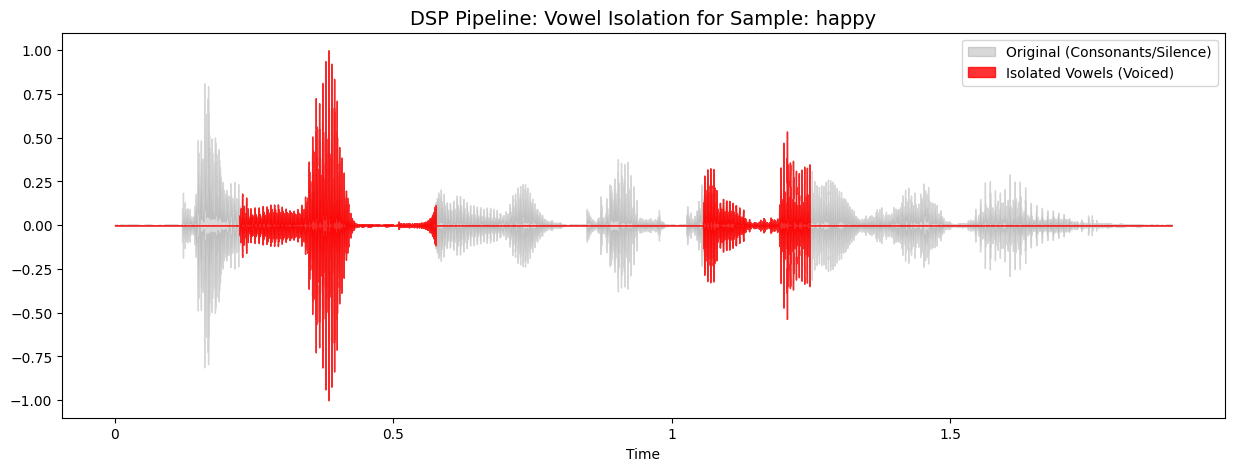

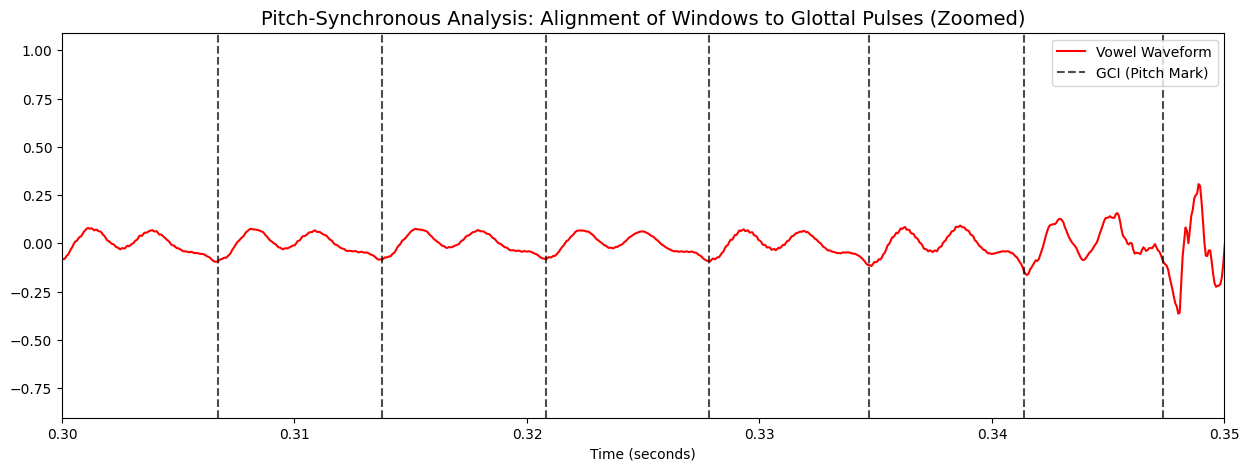

In [15]:
# --- NEW CELL: VISUALIZING THE DSP LOGIC ---

# Pick one sample file to visualize (e.g., the first one)
sample_y = X_audio[0]
sample_sr = 16000
sample_label = y_audio[0]

# 1. Plot the Vowel Isolation Pipeline
v_mask = isolate_vowels(sample_y, sample_sr)

plt.figure(figsize=(15, 5))
librosa.display.waveshow(sample_y, sr=sample_sr, alpha=0.3, color='gray', label='Original (Consonants/Silence)')
y_vowels = np.where(v_mask, sample_y, 0)
librosa.display.waveshow(y_vowels, sr=sample_sr, alpha=0.8, color='red', label='Isolated Vowels (Voiced)')
plt.title(f"DSP Pipeline: Vowel Isolation for Sample: {sample_label}", fontsize=14)
plt.legend()
plt.show()

# 2. Plot the Pitch-Synchronous Zoom (The "GCI" Plot)
marks = extract_pitch_marks_no_plot(sample_y, sample_sr, v_mask)

plt.figure(figsize=(15, 5))
t = np.linspace(0, len(sample_y)/sample_sr, len(sample_y))
plt.plot(t, sample_y, color='red', linewidth=1.5, label='Vowel Waveform')

# Plot vertical lines for GCIs
for m in marks:
    if 0.3 <= m <= 0.35: # Zoomed into a 50ms window
        plt.axvline(x=m, color='black', linestyle='--', alpha=0.7)

plt.xlim(0.3, 0.35) # Zoom in to see the individual waves
plt.title("Pitch-Synchronous Analysis: Alignment of Windows to Glottal Pulses (Zoomed)", fontsize=14)
plt.xlabel("Time (seconds)")
plt.legend(['Vowel Waveform', 'GCI (Pitch Mark)'])
plt.show()


--- MID-EVALUATION RESULTS TABLE ---
--- Evaluating: Setup 1: Standard MFCCs ---
Accuracy: 83.52%
--- Evaluating: Setup 2: Vowel-Only MFCCs ---
Accuracy: 65.93%
--- Evaluating: Setup 3: Pitch-Synchronous Vowel MFCCs ---
Accuracy: 64.29%

--- Generating Confusion Matrix for the Best Model (Setup 3) ---


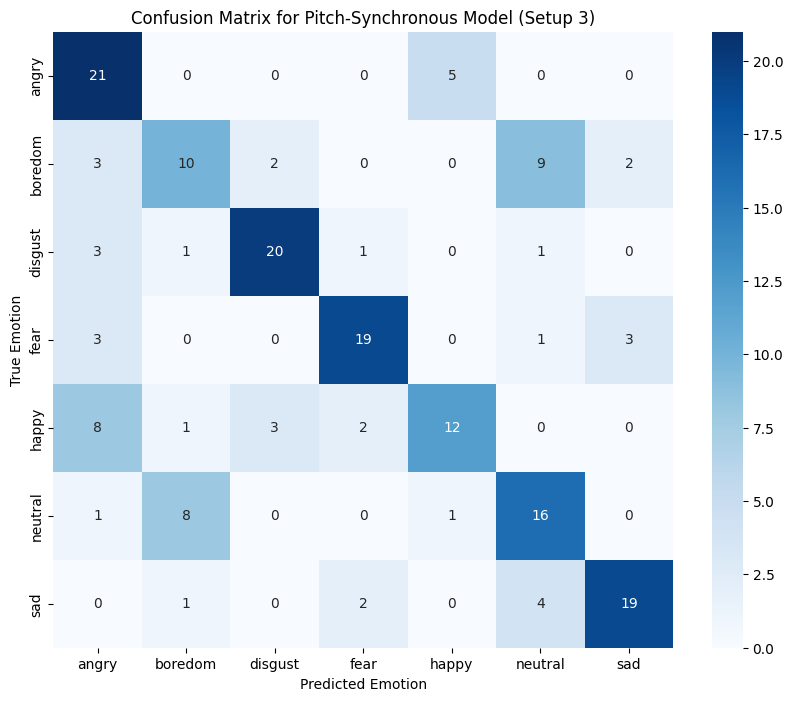

In [14]:
# --- PHASE 4: FINAL SVM ABLATION STUDY ---

# --- 1. Prepare Labels for Machine Learning ---
# We need to convert string labels ('angry', 'sad') to numbers (0, 1, 2...)
le = LabelEncoder()
y_encoded = le.fit_transform(y_audio)

# You can see the mapping by uncommenting the line below
# print(dict(zip(le.classes_, le.transform(le.classes_))))


# --- 2. Create the Training and Evaluation Function ---
def train_and_evaluate_svm(X_data, y_data, feature_set_name):
    """
    This function takes a feature set, splits it, scales it,
    trains an SVM, and returns the accuracy and test data for plotting.
    """
    print(f"--- Evaluating: {feature_set_name} ---")
    
    # Split data into 80% training and 20% testing
    # stratify=y_data ensures both sets have a balanced number of each emotion
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )
    
    # Scale the features (very important for SVMs!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize and train the Support Vector Machine
    model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on the unseen test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy * 100:.2f}%")
    return accuracy, y_test, y_pred

# --- 3. Run the Comparison! ---
print("\n--- MID-EVALUATION RESULTS TABLE ---")
acc1, _, _ = train_and_evaluate_svm(X1, y_encoded, "Setup 1: Standard MFCCs")
acc2, _, _ = train_and_evaluate_svm(X2, y_encoded, "Setup 2: Vowel-Only MFCCs")
acc3, y_test_final, y_pred_final = train_and_evaluate_svm(X3, y_encoded, "Setup 3: Pitch-Synchronous Vowel MFCCs")

# --- 4. Visualize the Best Model's Performance ---
print("\n--- Generating Confusion Matrix for the Best Model (Setup 3) ---")

# Create the confusion matrix
cm = confusion_matrix(y_test_final, y_pred_final)

# Plot it using a heatmap for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Pitch-Synchronous Model (Setup 3)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_25284\1235181092.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Approach', y='Accuracy', data=results_df, palette='magma')


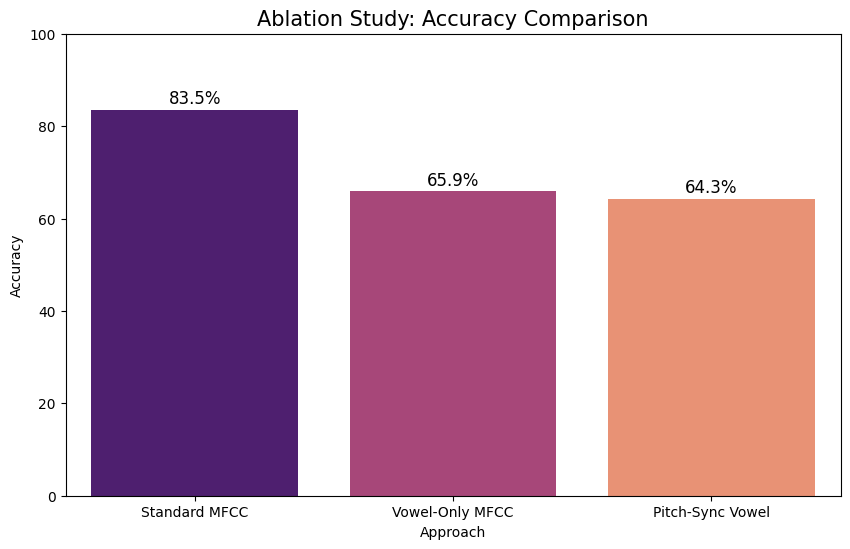

Visualizing why Setup 1 (Whole File) is easier for the SVM than Setup 3 (Pitch-Sync)...


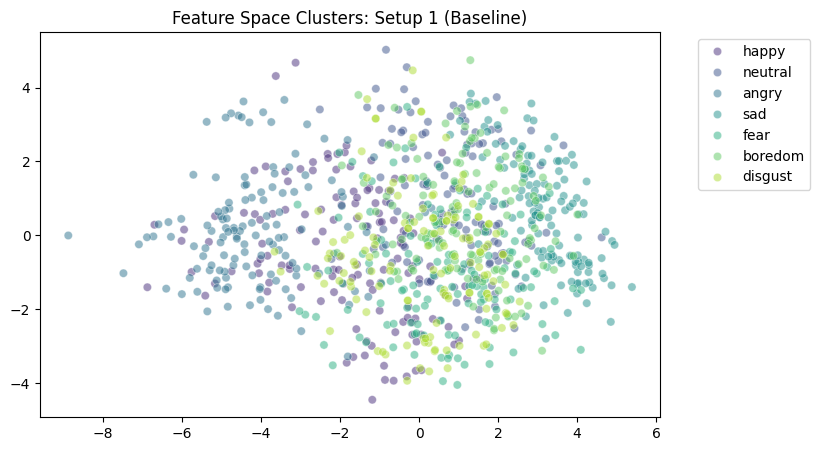

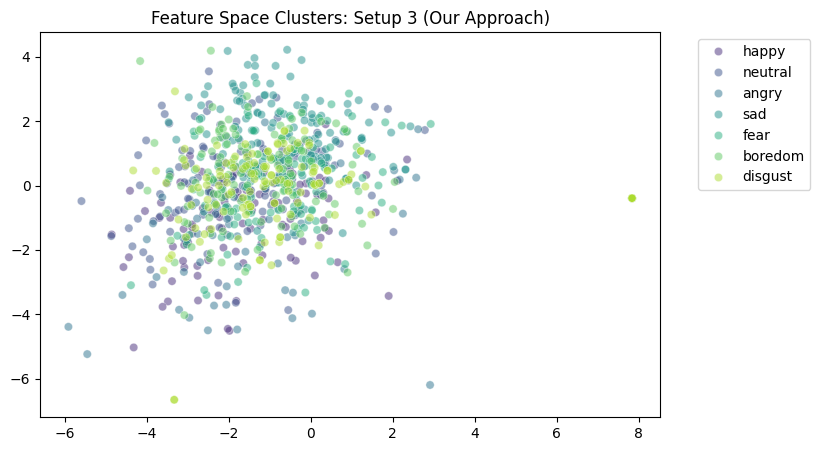

In [16]:
# --- NEW CELL: SUMMARY RESULTS & CLUSTER ANALYSIS ---

# 1. Plot the Accuracy Comparison Bar Chart
results_df = pd.DataFrame({
    'Approach': ['Standard MFCC', 'Vowel-Only MFCC', 'Pitch-Sync Vowel'],
    'Accuracy': [acc1*100, acc2*100, acc3*100]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Approach', y='Accuracy', data=results_df, palette='magma')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, xytext=(0, 8), textcoords='offset points')
plt.ylim(0, 100)
plt.title("Ablation Study: Accuracy Comparison", fontsize=15)
plt.show()

# 2. PCA Cluster Analysis (The "Why" Plot)
from sklearn.decomposition import PCA

def plot_clusters(X, title):
    pca = PCA(n_components=2)
    X_p = pca.fit_transform(StandardScaler().fit_transform(X))
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_p[:, 0], y=X_p[:, 1], hue=le.inverse_transform(y_encoded), palette='viridis', alpha=0.5)
    plt.title(f"Feature Space Clusters: {title}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Show Setup 1 vs Setup 3
print("Visualizing why Setup 1 (Whole File) is easier for the SVM than Setup 3 (Pitch-Sync)...")
plot_clusters(X1, "Setup 1 (Baseline)")
plot_clusters(X3, "Setup 3 (Our Approach)")